# Hyperparameters
 Кілька прикладів гіперпараметрів, які оптимізують для нейронних мереж:

1. <b>Кількість шарів (layers):</b> Кількість шарів у нейронній мережі визначається глибиною моделі.

2. <b>Кількість нейронів у кожному шарі (nodes):</b> Це кількість нейронів у кожному шарі нейронної мережі.

3. <b>Швидкість навчання (learning rate):</b> Це параметр, який визначає, наскільки швидко модель навчається під час процесу навчання.

4. <b>Функції активації (activation functions):</b> Вони використовуються для передачі сигналів між нейронами у шарах.

5. <b>Батч-розмір (batch size):</b> Кількість прикладів навчання, які використовуються в одному кроці оптимізації.

6. <b>Кількість епох (epochs):</b> Це кількість разів, коли весь набір даних пройшов через нейронну мережу під час навчання.

7. <b>Регуляризація (regularization):</b> Такі як L1 або L2 регуляризація, які допомагають уникнути перенавчання.

8. <b>Тип оптимізатора (optimizer):</b> Алгоритм, який використовується для оновлення ваг моделі під час навчання.

Тощо.

In [1]:
import pandas as pd
import gdown
import os

In [2]:
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download
# датасет по виявленю шахрайства з кредитною карткою
# https://drive.google.com/file/d/1NqSRvhHgKeDaAhS8RGAo5LRKE55WZ8UF/view?usp=sharing
file_id = '1NqSRvhHgKeDaAhS8RGAo5LRKE55WZ8UF'
url = f'https://drive.google.com/uc?id={file_id}'
# Завантажуємо файл з Google Drive у директоряю "../../data/credit_card_fraud/"
output = '../../data/credit_card_fraud/creditcard.csv'
gdown.download(url, output, quiet=False)
# Читаємо дані з CSV файлу
df = pd.read_csv(output)
os.remove(output)  # Видаляємо файл після читання
print(df.head())

Downloading...
From (original): https://drive.google.com/uc?id=1NqSRvhHgKeDaAhS8RGAo5LRKE55WZ8UF
From (redirected): https://drive.google.com/uc?id=1NqSRvhHgKeDaAhS8RGAo5LRKE55WZ8UF&confirm=t&uuid=8162dff1-5d8a-4bac-b991-133409c2c0fa
To: /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/credit_card_fraud/creditcard.csv
100%|██████████| 151M/151M [00:49<00:00, 3.06MB/s] 


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
len(df[df['Class'] == 1]) /len(df)

0.001727485630620034

In [5]:
df.head()
# В стовпці Class 1 - це шахрайські транзакції, а 0 - це нормальні транзакції. Всього 492 шахрайські транзакції серед 284807 транзакцій, що становить приблизно 0.172% від усіх транзакцій. Це означає, що дані є дуже незбалансованими, і для побудови моделі виявлення шахрайства потрібно враховувати цей факт.

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Load the Credit Card Fraud Detection dataset

# Separate features and target variable
X = df.drop('Class', axis=1).values
y = df['Class'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create PyTorch DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [7]:
train_dataset[0]

(tensor([ 1.4116,  0.9934, -0.4560, -0.8941, -0.4673,  1.0892,  3.0244, -1.1949,
          0.9571,  1.2814, -0.1445, -0.1108,  0.5093,  0.0621, -0.0696,  1.4511,
          0.4044, -0.9074,  0.1691, -0.5554, -0.1731,  0.1032,  0.4096,  0.4907,
          1.1420, -0.6708, -0.8072,  0.1919, -0.0991, -0.3225]),
 tensor([0.]))

In [8]:
train_loader.__dict__

{'dataset': <torch.utils.data.dataset.TensorDataset at 0x73ba73906e10>,
 'num_workers': 0,
 'prefetch_factor': None,
 'pin_memory': False,
 'pin_memory_device': '',
 'timeout': 0,
 'worker_init_fn': None,
 '_DataLoader__multiprocessing_context': None,
 'in_order': True,
 '_dataset_kind': 0,
 'batch_size': 128,
 'drop_last': False,
 'sampler': <torch.utils.data.sampler.RandomSampler at 0x73ba73b61590>,
 'batch_sampler': <torch.utils.data.sampler.BatchSampler at 0x73ba73b5be50>,
 'generator': None,
 'collate_fn': <function torch.utils.data._utils.collate.default_collate(batch)>,
 'persistent_workers': False,
 '_DataLoader__initialized': True,
 '_IterableDataset_len_called': None,
 '_iterator': None}

In [9]:
# use other metrict rather than accuracy, because of unbalanced data
predictions = torch.tensor([0] * len(y_test)) # if we naively classify all as 0
accuracy = (predictions == y_test_tensor).float().mean()
accuracy.item()

0.9982794523239136

In [10]:
y_test_tensor.sum()

tensor(98.)

In [11]:
len(y_test_tensor)

56962

In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score

def evaluate(y_test, predictions):
    print("Recall score (pos. 1):", recall_score(y_test.numpy(), predictions.numpy()))
    print("Precision score (pos. 1):", precision_score(y_test.numpy(), predictions.numpy()))
    print("F1 score (pos. 1):", f1_score(y_test.numpy(), predictions.numpy()))
    print("F1 score (weighted):", f1_score(y_test.numpy(), predictions.numpy(), average='weighted'))
    print("F1 score (micro):", f1_score(y_test.numpy(), predictions.numpy(), average='micro'))
    print("F1 score (macro):", f1_score(y_test.numpy(), predictions.numpy(), average='macro'))
    
evaluate(y_test_tensor, predictions)




Recall score (pos. 1): 0.0
Precision score (pos. 1): 0.0
F1 score (pos. 1): 0.0
F1 score (weighted): 0.9974200728063972
F1 score (micro): 0.9982795547909132
F1 score (macro): 0.4995695183877146


/home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/.ds_lect_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Build and optimize

## 1. Number of layers

In [13]:
# Build the neural network model
class FraudDetectionModel_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

In [27]:
def run_experiment(model, loss_recording_list, lr=0.01, train_loader=train_loader, epochs=1, optimizer=optim.SGD):
    # Define loss function and optimizer
    criterion = nn.BCELoss()
    # Stochastic Gradient Descent optimizer
    if lr:
        optimizer = optimizer(model.parameters(), lr=lr) # You may need to experiment with different learning rates
    else:
        optimizer = optimizer(model.parameters()) # Use default learning rate

    # Train the model
    loss_res = []
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            # Forward pass
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss_res.append(loss.item())
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
        print("Loss:", loss.item())
    loss_recording_list.append(loss_res)

    # Evaluate the model on the test set
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        predictions = (outputs.squeeze() > 0.5).float()

    evaluate(y_test_tensor, predictions)


In [ ]:
losses_expriment_1 = []

[]

In [28]:
model_1 = FraudDetectionModel_1()
run_experiment(model_1, losses_expriment_1)

Loss: 0.01542147807776928
Recall score (pos. 1): 0.0
Precision score (pos. 1): 0.0
F1 score (pos. 1): 0.0
F1 score (weighted): 0.9974200728063972
F1 score (micro): 0.9982795547909132
F1 score (macro): 0.4995695183877146


/home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/.ds_lect_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


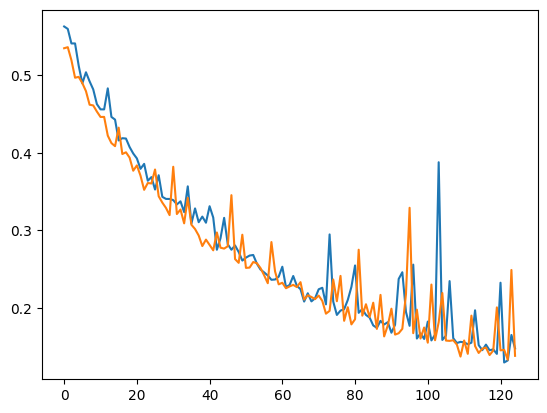

In [45]:
import matplotlib.pyplot as plt

x_axis = range(len(losses_expriment_1[0]))
for line in losses_expriment_1:
    plt.plot(x_axis[:125], line[:125])


In [34]:
# Add one more layer
class FraudDetectionModel_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

In [35]:
losses_expriment_2 = []

In [48]:
model_2 = FraudDetectionModel_2()
run_experiment(model_2, losses_expriment_2)

Loss: 0.006457722280174494
Recall score (pos. 1): 0.0
Precision score (pos. 1): 0.0
F1 score (pos. 1): 0.0
F1 score (weighted): 0.9974200728063972
F1 score (micro): 0.9982795547909132
F1 score (macro): 0.4995695183877146


/home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/.ds_lect_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


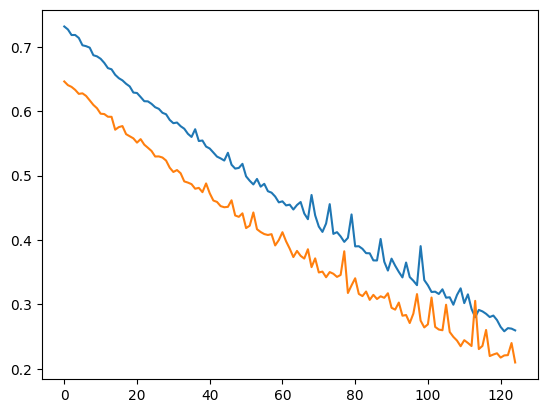

In [49]:
import matplotlib.pyplot as plt

x_axis = range(len(losses_expriment_2[0]))
for line in losses_expriment_2:
    plt.plot(x_axis[:125], line[:125])

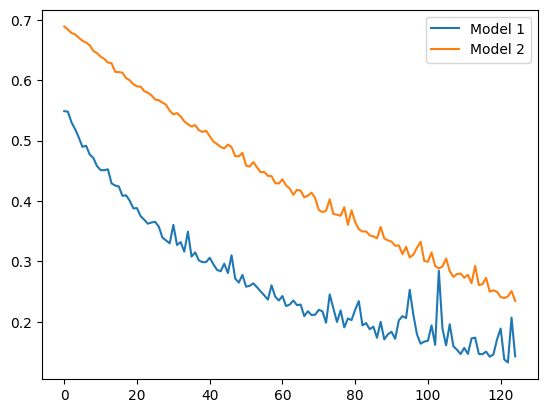

In [50]:
# Compare

losses_expriment_1_mean = np.array(losses_expriment_1).mean(axis=0)
losses_expriment_2_mean = np.array(losses_expriment_2).mean(axis=0)

plt.plot(x_axis[:125], losses_expriment_1_mean[:125], label='Model 1')
plt.plot(x_axis[:125], losses_expriment_2_mean[:125], label='Model 2')
plt.legend()

# 2. Number of Nodes

In [40]:
# Add more nodes
class FraudDetectionModel_3(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)        
        x = self.sigmoid(x)
        return x

In [41]:
losses_experiment_3 = []

In [52]:
model_3 = FraudDetectionModel_3()
run_experiment(model_3, losses_experiment_3)


Loss: 0.004724040161818266
Recall score (pos. 1): 0.0
Precision score (pos. 1): 0.0
F1 score (pos. 1): 0.0
F1 score (weighted): 0.9974200728063972
F1 score (micro): 0.9982795547909132
F1 score (macro): 0.4995695183877146


/home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/.ds_lect_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


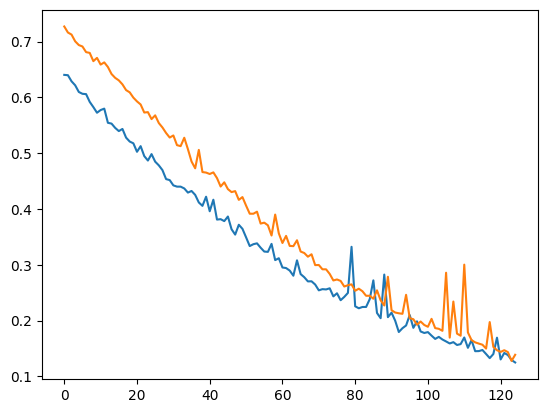

In [53]:
import matplotlib.pyplot as plt

x_axis = range(len(losses_experiment_3[0]))
for line in losses_experiment_3:
    plt.plot(x_axis[:125], line[:125])

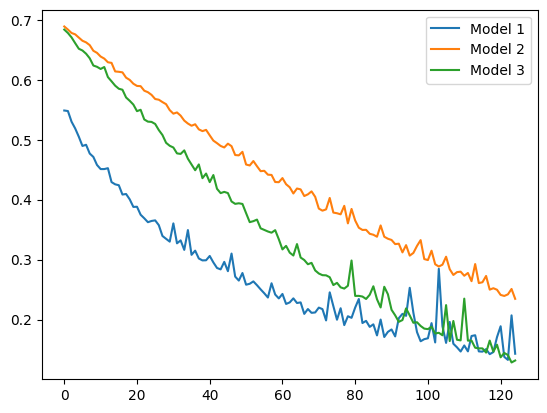

In [54]:
# Compare

losses_expriment_1_mean = np.array(losses_expriment_1).mean(axis=0)
losses_expriment_2_mean = np.array(losses_expriment_2).mean(axis=0)
losses_experiment_3_mean = np.array(losses_experiment_3).mean(axis=0)

plt.plot(x_axis[:125], losses_expriment_1_mean[:125], label='Model 1')
plt.plot(x_axis[:125], losses_expriment_2_mean[:125], label='Model 2')
plt.plot(x_axis[:125], losses_experiment_3_mean[:125], label='Model 3')
plt.legend()    

In [55]:
# Return to the simple model and increase number of nodes

class FraudDetectionModel_4(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 128*2)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128*2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

In [56]:
losses_experiment_4 = []

In [57]:
model_4 = FraudDetectionModel_4()
run_experiment(model_4, losses_experiment_4)

Loss: 0.007323796860873699
Recall score (pos. 1): 0.0
Precision score (pos. 1): 0.0
F1 score (pos. 1): 0.0
F1 score (weighted): 0.9974200728063972
F1 score (micro): 0.9982795547909132
F1 score (macro): 0.4995695183877146


/home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/.ds_lect_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


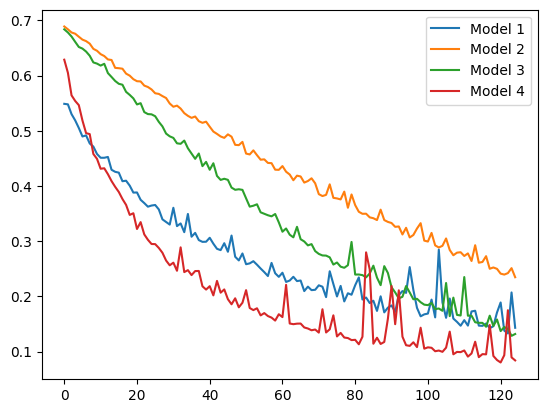

In [58]:
# Compare
losses_expriment_1_mean = np.array(losses_expriment_1).mean(axis=0)
losses_expriment_2_mean = np.array(losses_expriment_2).mean(axis=0)
losses_experiment_3_mean = np.array(losses_experiment_3).mean(axis=0)
losses_experiment_4_mean = np.array(losses_experiment_4).mean(axis=0)

plt.plot(x_axis[:125], losses_expriment_1_mean[:125], label='Model 1')
plt.plot(x_axis[:125], losses_expriment_2_mean[:125], label='Model 2')
plt.plot(x_axis[:125], losses_experiment_3_mean[:125], label='Model 3')
plt.plot(x_axis[:125], losses_experiment_4_mean[:125], label='Model 4')
plt.legend()

# 3. Learning rate

In [59]:
losses_experiment_5 = []

In [60]:
model_5 = FraudDetectionModel_4()

run_experiment(model_5, losses_experiment_5, lr=0.02)

Loss: 0.002808384131640196
Recall score (pos. 1): 0.3877551020408163
Precision score (pos. 1): 0.7755102040816326
F1 score (pos. 1): 0.5170068027210885
F1 score (weighted): 0.9985460825698781
F1 score (micro): 0.99875355500158
F1 score (macro): 0.758191387508887


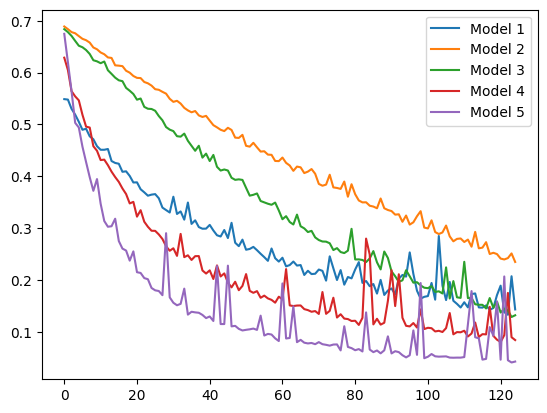

In [61]:
# Compare
losses_expriment_1_mean = np.array(losses_expriment_1).mean(axis=0)
losses_expriment_2_mean = np.array(losses_expriment_2).mean(axis=0)
losses_experiment_3_mean = np.array(losses_experiment_3).mean(axis=0)
losses_experiment_4_mean = np.array(losses_experiment_4).mean(axis=0)
losses_experiment_5_mean = np.array(losses_experiment_5).mean(axis=0)

plt.plot(x_axis[:125], losses_expriment_1_mean[:125], label='Model 1')
plt.plot(x_axis[:125], losses_expriment_2_mean[:125], label='Model 2')
plt.plot(x_axis[:125], losses_experiment_3_mean[:125], label='Model 3')
plt.plot(x_axis[:125], losses_experiment_4_mean[:125], label='Model 4')
plt.plot(x_axis[:125], losses_experiment_5_mean[:125], label='Model 5')
plt.legend()    

# 4. Activation function
https://medium.com/@juanc.olamendy/understanding-relu-leakyrelu-and-prelu-a-comprehensive-guide-20f2775d3d64

In [ ]:
# Replace ReLU with PReLU

class FraudDetectionModel_6(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 128*2)
        self.prelu1 = nn.PReLU()
        self.fc2 = nn.Linear(128*2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.prelu1(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x